# Divar Real Estate Analysis — Descriptive Statistics

**Questions:**
- **Q8:** Correlation Matrix of Price, Size, Capacity, Rooms and Location
- **Q9:** Regional Distribution of Properties with Balcony, Elevator, Security Guard, Barbecue and Pool

**Author:** Mahdi Tarrah

**Data:** `data/Divar.csv`

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


## Q8 — Correlation Matrix of Price, Size, Capacity, Rooms and Location

In [2]:
#cheak 1000 narrow
df_cheak = pd.read_csv('../data/Divar.csv', nrows=1000)

In [3]:
#cheak datatypes of each columns
df_cheak.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 61 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Unnamed: 0                  1000 non-null   int64  
 1   cat2_slug                   1000 non-null   str    
 2   cat3_slug                   1000 non-null   str    
 3   city_slug                   1000 non-null   str    
 4   neighborhood_slug           438 non-null    str    
 5   created_at_month            1000 non-null   str    
 6   user_type                   288 non-null    str    
 7   description                 1000 non-null   str    
 8   title                       1000 non-null   str    
 9   rent_mode                   330 non-null    str    
 10  rent_value                  328 non-null    float64
 11  rent_to_single              0 non-null      float64
 12  rent_type                   101 non-null    str    
 13  price_mode                  599 non-null    s

In [4]:
#see data
df_cheak.head()

,Unnamed: 0,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,...,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
0,0,temporary-rent,villa,karaj,mehrshahr,2024-08-01 00:00:00,مشاور املاک,۵۰۰متر\n۲۰۰متر بنا دوبلکس\n۳خواب\nاستخر آبگرم ...,باغ ویلا اجاره روزانه استخر داخل لشکرآباد سهیلیه,NaN,...,NaN,4.0,6.0,350000.0,1500000.0,3.500000e+09,3500000.0,35.811684,50.936600,500.0
1,1,residential-sell,apartment-sell,tehran,gholhak,2024-05-01 00:00:00,مشاور املاک,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.0
2,2,residential-rent,apartment-rent,tehran,tohid,2024-10-01 00:00:00,NaN,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,مقطوع,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.703865,51.373459,NaN
3,3,commercial-rent,office-rent,tehran,elahiyeh,2024-06-01 00:00:00,NaN,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,مقطوع,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,residential-sell,apartment-sell,mashhad,emamreza,2024-05-01 00:00:00,مشاور املاک,هلدینگ ساختمانی اکبری\n\nهمراه شما هستیم برای ...,۱۱۵ متری/شمالی رو به آفتاب/اکبری,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
#read all columns we need for Q8
q8_columns = ['price_value','land_size','building_size','regular_person_capacity','rooms_count','location_latitude','location_longitude','city_slug','cat3_slug']
df = pd.read_csv('../data/Divar.csv', usecols=q8_columns)
df.shape

(1000000, 9)

In [6]:
#cheak_nulls
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 9 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   cat3_slug                999999 non-null  str    
 1   city_slug                999998 non-null  str    
 2   price_value              568346 non-null  float64
 3   land_size                186396 non-null  float64
 4   building_size            980394 non-null  float64
 5   rooms_count              845899 non-null  str    
 6   regular_person_capacity  29870 non-null   float64
 7   location_latitude        655608 non-null  float64
 8   location_longitude       655608 non-null  float64
dtypes: float64(6), str(3)
memory usage: 68.7 MB


In [7]:
#cheak for impossible value
df.describe().T

,count,mean,std,min,25%,50%,75%,max
price_value,568346.0,1.736537e+10,5.878739e+11,0.000000,1.400000e+09,2.840000e+09,5.900000e+09,1.000000e+14
land_size,186396.0,4.165480e+03,1.218927e+05,1.000000,1.100000e+02,1.950000e+02,2.800000e+02,1.000000e+07
building_size,980394.0,4.440648e+03,1.367118e+05,1.000000,7.500000e+01,1.030000e+02,1.650000e+02,1.000000e+07
regular_person_capacity,29870.0,6.557650e+00,7.698655e+00,1.000000,3.000000e+00,4.000000e+00,7.000000e+00,5.000000e+01
location_latitude,655608.0,3.498211e+01,2.379169e+00,23.626478,3.455355e+01,3.572331e+01,3.630701e+01,4.035806e+01
location_longitude,655608.0,5.162974e+01,3.160920e+00,40.162369,5.067717e+01,5.134579e+01,5.180529e+01,7.451162e+01


In [8]:
#cheak values of rooms_count
df['rooms_count'].value_counts(dropna=False)

rooms_count
دو              404050
یک              192083
NaN             154101
سه              138633
بدون اتاق        75898
چهار             21371
پنج یا بیشتر     13864
Name: count, dtype: int64

<p dir="rtl" align="right"><font color="#90EE90" face="vazir">
قیمت صفر را انداختم چون قیمت واقعی نیست و مال آگهی توافقی است و برای داده پرت هم اول لگاریتم گرفتم بعد IQR زدم چون توزیع قیمت و متراژ خیلی چوله است و IQR مستقیم کلی ملک گران واقعی را هم پرت حساب می‌کرد و با این کار حدود ۵.۸ درصد قیمت‌ها و ۹.۴ درصد زیربناها و ۳.۸ درصد متراژ زمین‌ها حذف شد که برای داده آگهی کاربرپسند طبیعی است و تعداد اتاق هم متن بود که به عدد صفر تا پنج تبدیلش کردم و مختصات بیرون از ایران را هم پاک کردم که فقط ۴۷ ردیف بود
</font></p>

In [9]:
#copy
df_q8 = df.copy()

#cheak data

print(df_q8['price_value'].quantile([0.99, 0.999, 0.9999]))
print(df_q8['price_value'].sort_values(ascending=False).head(20))

print(df_q8['land_size'].quantile([0.99, 0.999, 0.9999]))
print(df_q8['land_size'].sort_values(ascending=False).head(20))

print(df_q8['building_size'].quantile([0.99, 0.999, 0.9999]))
print(df_q8['building_size'].sort_values(ascending=False).head(20))


#cleaning data
q8_mapping = {'بدون اتاق':0,'یک':1,'دو':2,'سه':3,'چهار':4,'پنج یا بیشتر':5}

df_q8['rooms_count'] = df_q8['rooms_count'].map(q8_mapping)

df_q8.loc[df_q8['price_value'] <= 0, 'price_value'] = np.nan
df_q8.loc[df_q8['land_size'] <= 0, 'land_size'] = np.nan
df_q8.loc[df_q8['building_size'] <= 0, 'building_size'] = np.nan

def clean_outliers_log(data, column):
    """Set values outside the IQR fences of log(column) to NaN."""
    logs = np.log(data[column])
    q1, q3 = logs.quantile(0.25), logs.quantile(0.75)
    iqr = q3 - q1
    data.loc[~logs.between(q1 - 1.5 * iqr, q3 + 1.5 * iqr), column] = np.nan
    return data


columns_cheak_outlier = ['land_size', 'price_value', 'building_size']
for column in columns_cheak_outlier:
    print('before:', df_q8[column].isna().sum())
    df_q8 = clean_outliers_log(df_q8, column)
    print('after:', df_q8[column].isna().sum())

df_q8.loc[~((df_q8['location_latitude'].between(25, 40)) & (df_q8['location_longitude'].between(44, 63.5))), ['location_latitude', 'location_longitude']] = np.nan
print(df_q8.isna().sum())

df_q8.describe().T

0.9900    8.500000e+10
0.9990    1.111111e+12
0.9999    1.970000e+13
Name: price_value, dtype: float64
329748    1.000000e+14
116854    1.000000e+14
588194    1.000000e+14
786984    1.000000e+14
931774    1.000000e+14
927290    1.000000e+14
740491    1.000000e+14
6406      9.000000e+13
560251    8.900000e+13
339009    8.397000e+13
306779    8.000086e+13
178219    7.000000e+13
388408    6.400000e+13
9201      6.300000e+13
703415    6.160000e+13
51259     6.000000e+13
209643    5.150000e+13
328774    5.000000e+13
564384    5.000000e+13
60067     5.000000e+13
Name: price_value, dtype: float64
0.9900    4.320650e+03
0.9990    1.100000e+06
0.9999    8.180250e+06
Name: land_size, dtype: float64
176035    10000000.0
145526    10000000.0
535334    10000000.0
534250    10000000.0
229017    10000000.0
905101    10000000.0
901197    10000000.0
336726    10000000.0
171954    10000000.0
173270    10000000.0
481516    10000000.0
449438    10000000.0
734403    10000000.0
236786     9250000.0
331890  

,count,mean,std,min,25%,50%,75%,max
price_value,535564.0,5.088866e+09,6.479189e+09,1.640000e+08,1.500000e+09,2.950000e+09,5.810000e+09,5.100000e+10
land_size,179384.0,2.292650e+02,1.848719e+02,2.800000e+01,1.100000e+02,1.850000e+02,2.600000e+02,1.137000e+03
building_size,887827.0,1.274276e+02,8.525152e+01,2.300000e+01,7.500000e+01,1.000000e+02,1.500000e+02,5.380000e+02
rooms_count,845899.0,1.857061e+00,9.889369e-01,0.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00,5.000000e+00
regular_person_capacity,29870.0,6.557650e+00,7.698655e+00,1.000000e+00,3.000000e+00,4.000000e+00,7.000000e+00,5.000000e+01
location_latitude,655561.0,3.498264e+01,2.377957e+00,2.501717e+01,3.455394e+01,3.572332e+01,3.630702e+01,3.980854e+01
location_longitude,655561.0,5.162953e+01,3.160282e+00,4.400128e+01,5.067718e+01,5.134577e+01,5.180507e+01,6.284333e+01


In [10]:
q8_cols = ['price_value','land_size','building_size','regular_person_capacity','rooms_count','location_latitude','location_longitude']
pair_counts = pd.DataFrame(index=q8_cols, columns=q8_cols)

for a in q8_cols:
    for b in q8_cols:
        both = (df_q8[a].notna()) & (df_q8[b].notna())
        pair_counts.loc[a, b] = both.sum()

pair_counts

,price_value,land_size,building_size,regular_person_capacity,rooms_count,location_latitude,location_longitude
price_value,535564,108086,493000,0,432391,352058,352058
land_size,108086,179384,173862,0,179384,109401,109401
building_size,493000,173862,887827,23025,790574,585931,585931
regular_person_capacity,0,0,23025,29870,29870,19448,19448
rooms_count,432391,179384,790574,29870,845899,559277,559277
location_latitude,352058,109401,585931,19448,559277,655561,655561
location_longitude,352058,109401,585931,19448,559277,655561,655561


<p dir="rtl" align="right"><font color="#90EE90" face="vazir">
این جدول می‌گوید پشت هر خانه ماتریس چند ردیف است و قیمت با ظرفیت نفرات صفر ردیف مشترک دارد چون ظرفیت نفرات فقط برای ویلا و سوئیت روزانه پر می‌شود ولی قیمت مال آگهی فروش است پس آن خانه در ماتریس خالی می‌ماند
</font></p>

                         price_value  land_size  building_size  \
price_value                 1.000000   0.225383       0.218375   
land_size                   0.225383   1.000000       0.331325   
building_size               0.218375   0.331325       1.000000   
regular_person_capacity          NaN        NaN       0.223118   
rooms_count                 0.349004   0.203978       0.560222   
location_latitude           0.024414   0.058515      -0.061798   
location_longitude         -0.002199   0.033481       0.025758   

                         regular_person_capacity  rooms_count  \
price_value                                  NaN     0.349004   
land_size                                    NaN     0.203978   
building_size                           0.223118     0.560222   
regular_person_capacity                 1.000000     0.344266   
rooms_count                             0.344266     1.000000   
location_latitude                      -0.046471    -0.021110   
location_longitu

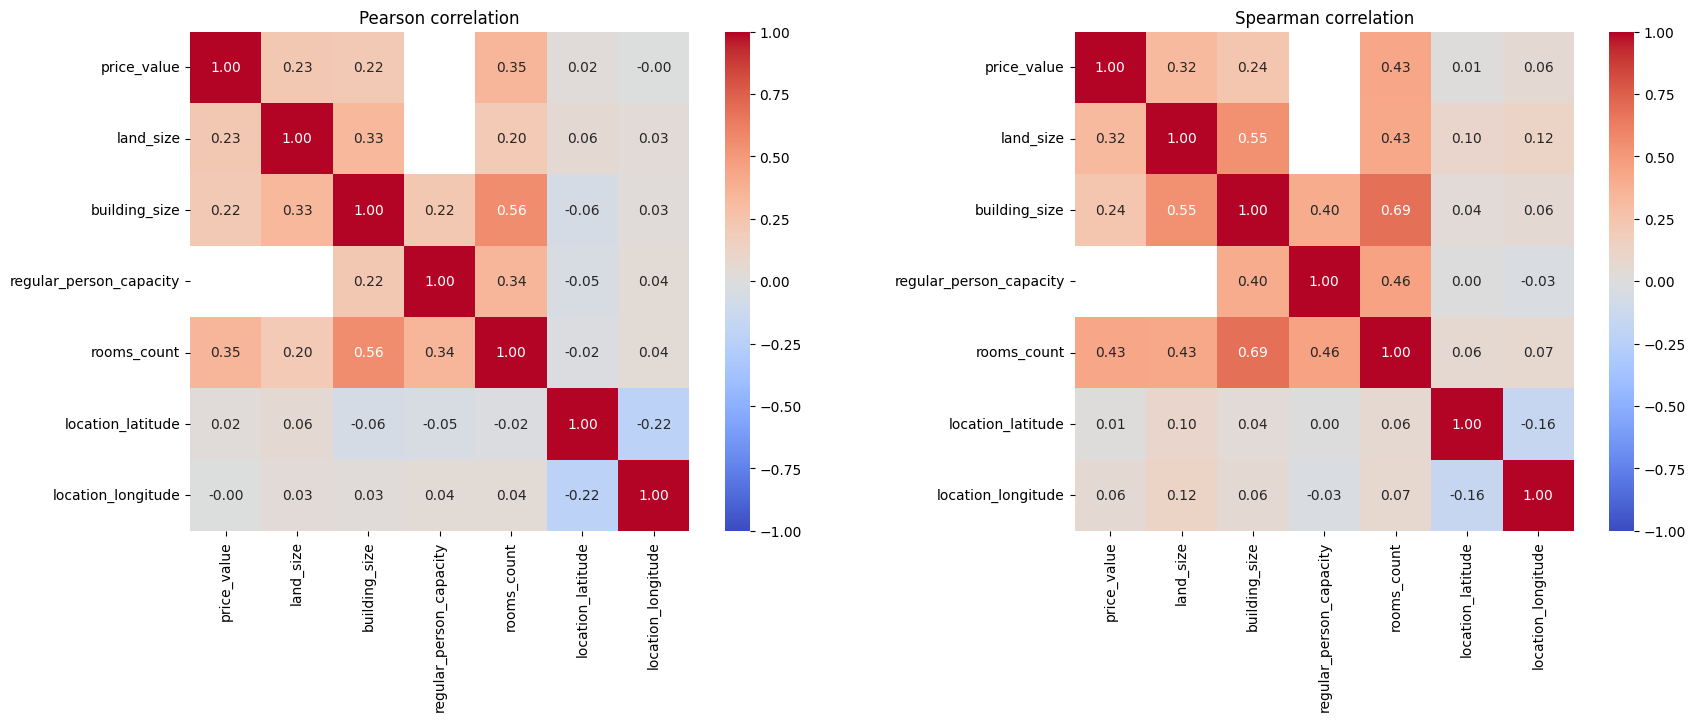

In [11]:
#corr
corr_pearson = df_q8[q8_cols].corr()
corr_spearman = df_q8[q8_cols].corr(method='spearman')

print(corr_pearson)
print(corr_spearman)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(corr_pearson, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True, ax=axes[0])
axes[0].set_title('Pearson correlation')

sns.heatmap(corr_spearman, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True, ax=axes[1])
axes[1].set_title('Spearman correlation')

plt.tight_layout()
plt.show()

<p dir="rtl" align="right"><font color="#90EE90" face="vazir">
هم پیرسون هم اسپیرمن رو حساب کردم چون پیرسون فرض نرمال بودن داره و فقط رابطه خطی رو می‌بینه ولی داده ما خیلی چولست و اسپیرمن چون روی رتبه‌ها کار می‌کنه نه خود عددها به چوله بودن و داده پرت حساس نیست و هر رابطه یکنواختی رو نشون میده پس برای این داده معیار مطمئن‌تریه
</font></p>

In [12]:
print(df_q8['city_slug'].value_counts().head())
print(df_q8['cat3_slug'].value_counts().head())

city_slug
tehran     190904
mashhad     69032
karaj       49367
shiraz      37141
isfahan     36953
Name: count, dtype: int64
cat3_slug
apartment-sell      303385
apartment-rent      211880
plot-old            133570
house-villa-sell    121753
house-villa-rent     64678
Name: count, dtype: int64


(84586, 9)
                    price_value  building_size  rooms_count  \
price_value            1.000000       0.813480     0.653539   
building_size          0.813480       1.000000     0.809879   
rooms_count            0.653539       0.809879     1.000000   
location_latitude      0.297892       0.221820     0.190861   
location_longitude     0.080948       0.033873     0.011717   

                    location_latitude  location_longitude  
price_value                  0.297892            0.080948  
building_size                0.221820            0.033873  
rooms_count                  0.190861            0.011717  
location_latitude            1.000000           -0.322409  
location_longitude          -0.322409            1.000000  
                    price_value  building_size  rooms_count  \
price_value            1.000000       0.822727     0.699217   
building_size          0.822727       1.000000     0.866317   
rooms_count            0.699217       0.866317     1.000000  

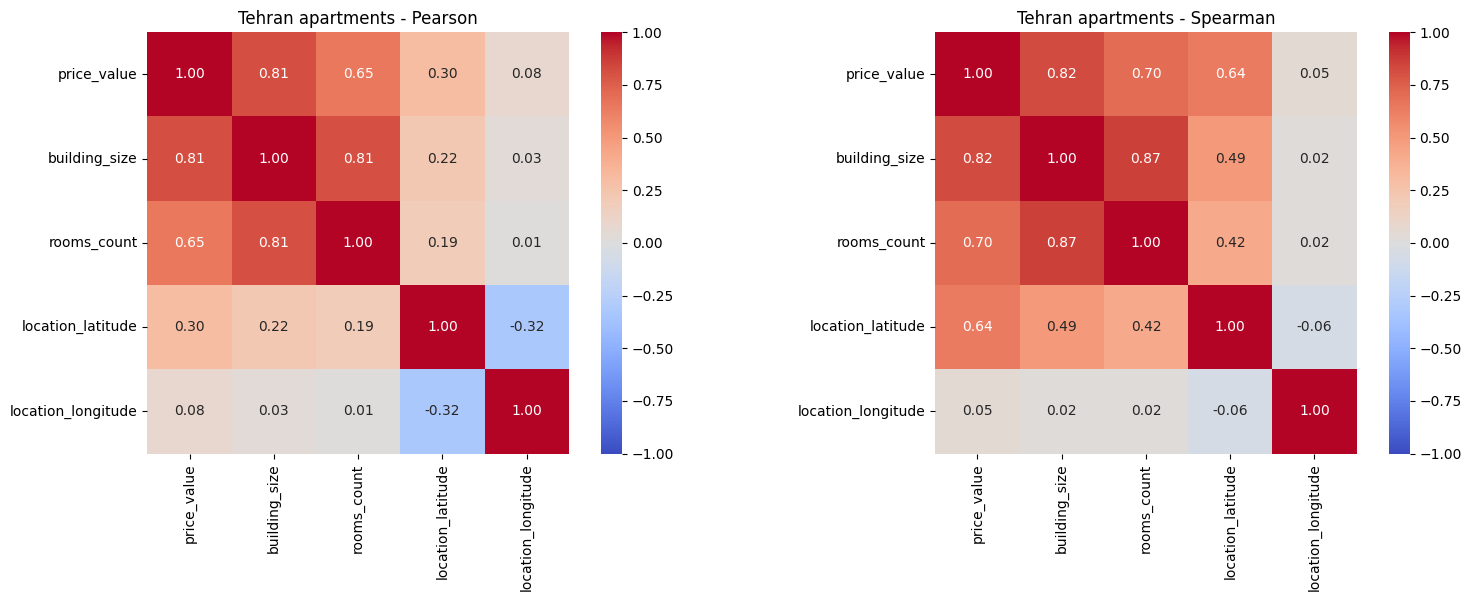

In [13]:
subset = df_q8[(df_q8['city_slug'] == 'tehran') & (df_q8['cat3_slug'] == 'apartment-sell')]
print(subset.shape)

subset_cols = ['price_value','building_size','rooms_count','location_latitude','location_longitude']

corr_subset_pearson = subset[subset_cols].corr()
corr_subset_spearman = subset[subset_cols].corr(method='spearman')

print(corr_subset_pearson)
print(corr_subset_spearman)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(corr_subset_pearson, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True, ax=axes[0])
axes[0].set_title('Tehran apartments - Pearson')

sns.heatmap(corr_subset_spearman, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True, ax=axes[1])
axes[1].set_title('Tehran apartments - Spearman')

plt.tight_layout()
plt.show()

<p dir="rtl" align="right"><font color="#90EE90" face="vazir">
برای امتحان حدسم همان ماتریس را فقط روی آپارتمان فروشی تهران گرفتم که بزرگ‌ترین گروه همگن است و قیمت با زیربنا از ۰.۲۲ رفت روی ۰.۸۱ و با عرض جغرافیایی از صفر به ۰.۳۰ یعنی رابطه از اول بود ولی زیر قاطی شدن شهرها و انواع ملک گم شده بود و متراژ زمین هم اینجا خالی است چون آپارتمان زمین ثبت نمی‌کند و محدودیتش این است که IQR سقف زیربنا را ۵۳۸ متر گذاشت و ویلاهای بزرگ بیرون افتادند
</font></p>

<p dir="rtl" align="right"><font color="#90EE90" face="vazir">
اینجا پیرسون و اسپیرمن تقریبا یکی شدن یعنی تو یه گروه همگن که داده تمیزه هر دو روش یه چیزو میگن ولی تو ماتریس کلی که همه نوع ملک قاطی بود بیشتر با هم فرق داشتن که نشون میده اون اختلاف از چوله بودن و قاطی بودن داده میومد
</font></p>

count    4.683530e+05
mean     4.345253e+07
std      3.999928e+07
min      3.067485e+06
25%      1.846154e+07
50%      3.088235e+07
75%      5.284553e+07
max      2.797203e+08
Name: price_per_m2, dtype: float64
                    price_value  price_per_m2  building_size  \
price_value            1.000000      0.866699       0.817888   
price_per_m2           0.866699      1.000000       0.540172   
building_size          0.817888      0.540172       1.000000   
location_latitude      0.575340      0.650103       0.462727   
location_longitude     0.117926      0.135198       0.052590   

                    location_latitude  location_longitude  
price_value                  0.575340            0.117926  
price_per_m2                 0.650103            0.135198  
building_size                0.462727            0.052590  
location_latitude            1.000000           -0.058049  
location_longitude          -0.058049            1.000000  


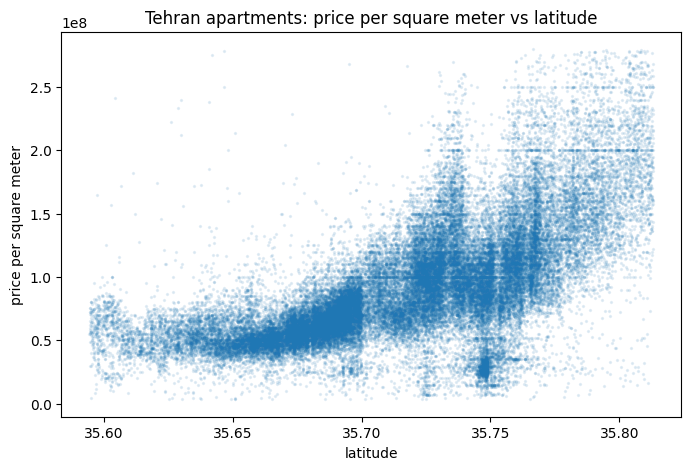

In [14]:
#feature: price per square meter
df_q8['price_per_m2'] = df_q8['price_value']/df_q8['building_size']
df_q8 = clean_outliers_log(df_q8, 'price_per_m2')

#check
print(df_q8['price_per_m2'].describe())

#Tehran apartments with the new feature
subset2 = df_q8[(df_q8['city_slug'] == 'tehran') & (df_q8['cat3_slug'] == 'apartment-sell')]
lat_low, lat_high = subset2['location_latitude'].quantile([0.01, 0.99])
lon_low, lon_high = subset2['location_longitude'].quantile([0.01, 0.99])

subset2 = subset2[subset2['location_latitude'].between(lat_low, lat_high) & subset2['location_longitude'].between(lon_low, lon_high)]

check_cols = ['price_value', 'price_per_m2', 'building_size','location_latitude', 'location_longitude']
print(subset2[check_cols].corr())

#plt
plt.figure(figsize=(8, 5))
plt.scatter(subset2['location_latitude'], subset2['price_per_m2'], s=2, alpha=0.1)
plt.xlabel('latitude')
plt.ylabel('price per square meter')
plt.title('Tehran apartments: price per square meter vs latitude')
plt.show()

<p dir="rtl" align="right"><font color="#90EE90" face="vazir">
یه ویژگی جدید ساختم یعنی قیمت هر متر مربع چون قیمت کل هم بزرگی ملک رو توش داره هم گرونی منطقه رو و وقتی تقسیم بر متراژ کنی اثر بزرگی میره کنار و فقط گرونی منطقه می‌مونه و نتیجه هم همینو نشون داد چون همبستگی قیمت کل با عرض جغرافیایی ۰.۳۰ بود ولی قیمت متری شد ۰.۵۴ و تو نمودار هم تا حدود ۳۵.۷ صافه و بعدش تند بالا میره که همون مرز جنوب و مرکز تهران با شمال شهره
</font></p>

## Q9 — Regional Distribution of Properties with Balcony, Elevator, Security Guard, Barbecue and Pool

In [15]:
#read all columns we need for Q9
q9_columns = ['has_balcony','has_elevator','has_security_guard','has_barbecue','has_pool','city_slug','cat3_slug']
df_q9 = pd.read_csv('../data/Divar.csv', usecols=q9_columns)
df_q9.shape

(1000000, 7)

In [16]:
#cheak values
options_cols = ['has_balcony','has_elevator','has_security_guard','has_barbecue','has_pool']

for col in options_cols:
    print(df_q9[col].value_counts(dropna=False))

def clean_boolean_columns(data,options):
    """convert mixed true/false values (bool and string) to 1 and 0 also Anything else becomes NaN."""
    mapping = {True: 1, 'true': 1, 'True': 1, False: 0, 'false': 0, 'False': 0}
    for col in options:
        data[col] = data[col].map(mapping)
    return data
df_q9 = clean_boolean_columns(df_q9, options_cols)

for col in options_cols:
    print(df_q9[col].value_counts(dropna=False))


has_balcony
NaN         493589
true        392096
false        88855
True         20692
False         4545
unselect       223
Name: count, dtype: int64
has_elevator
NaN      458251
True     365148
False    176601
Name: count, dtype: int64
has_security_guard
NaN      968688
False     24631
True       6681
Name: count, dtype: int64
has_barbecue
NaN      968802
False     23377
True       7821
Name: count, dtype: int64
has_pool
NaN      970610
False     25669
True       3721
Name: count, dtype: int64
has_balcony
NaN    493812
1.0    412788
0.0     93400
Name: count, dtype: int64
has_elevator
NaN    458251
1.0    365148
0.0    176601
Name: count, dtype: int64
has_security_guard
NaN    968688
0.0     24631
1.0      6681
Name: count, dtype: int64
has_barbecue
NaN    968802
0.0     23377
1.0      7821
Name: count, dtype: int64
has_pool
NaN    970610
0.0     25669
1.0      3721
Name: count, dtype: int64


<p dir="rtl" align="right"><font color="#90EE90" face="vazir">
ستون بالکن پنج شکل مختلف داشت یعنی true و True و false و False و unselect ولی بقیه ستون‌ها فقط بولی بودند پس همه را با یک تابع به صفر و یک تبدیل کردم تا یکدست شوند و unselect را خالی گذاشتم نه صفر چون کاربر اصلا جواب نداده و نمی‌دانیم دارد یا ندارد و اگر صفر بگیرم چیزی به داده اضافه کرده‌ام که در واقعیت نیست
</font></p>

In [17]:
#cheak options on cat3_slug
df_q9.groupby('cat3_slug')[options_cols].count()

,has_balcony,has_elevator,has_security_guard,has_barbecue,has_pool
cat3_slug,,,,,
apartment-rent,125302,211867,0,0,0
apartment-sell,194485,303378,1,1,1
house-villa-rent,64663,0,5021,5107,4991
house-villa-sell,121737,0,22211,21841,20234
industry-agriculture-business-rent,0,0,0,0,0
industry-agriculture-business-sell,0,1,0,0,0
office-rent,0,21348,0,0,0
office-sell,0,5155,0,0,0
partnership,0,0,0,0,0


In [18]:
#cheak data
print(df_q9[options_cols].notna().all(axis=1).sum())
print(df_q9[['has_balcony','has_elevator']].notna().all(axis=1).sum())
print(df_q9[['has_security_guard','has_barbecue','has_pool']].notna().all(axis=1).sum())
print(df_q9['city_slug'].nunique())
print(df_q9['city_slug'].isna().mean())

0
319787
28842
421
2e-06


In [19]:
#count and mean groupby on city_slug
counts = df_q9.groupby('city_slug')[options_cols].count()
shares = df_q9.groupby('city_slug')[options_cols].mean()

shares_ok = shares[counts >= 200]

for col in options_cols:
    print(col)
    print(shares_ok[col].dropna().sort_values(ascending=False).head(10))
    print()

has_balcony
city_slug
pardis-city          0.991299
garmdareh            0.985294
parand-city          0.983022
kelarabad            0.975124
andisheh-new-town    0.966881
izadshahr            0.961864
nashtarud            0.961373
nowshahr             0.960497
rudehen              0.957570
sorkhrood            0.953166
Name: has_balcony, dtype: float64

has_elevator
city_slug
garmdareh       0.958684
sorkhrood       0.945122
pardis-city     0.930835
sadra           0.883479
izadshahr       0.862069
urmia           0.861374
babolsar        0.854563
parand-city     0.851244
gonbad-kavus    0.846405
kahrizak        0.845347
Name: has_elevator, dtype: float64

has_security_guard
city_slug
chamestan       0.509036
nur             0.469666
royan           0.420875
mahmudabad      0.396364
izadshahr       0.371212
amol            0.336612
nowshahr        0.334525
sorkhrood       0.330793
salman-shahr    0.308571
kelarestan      0.259649
Name: has_security_guard, dtype: float64

has_barbecue


In [20]:
#sum groupby on city_slug
totals = df_q9.groupby('city_slug')[options_cols].sum()

for col in options_cols:
    print(col)
    print(totals[col].dropna().sort_values(ascending=False).head(10))
    print()

has_balcony
city_slug
tehran               90464.0
mashhad              28854.0
karaj                26013.0
isfahan              15225.0
shiraz               13566.0
andisheh-new-town    13546.0
tabriz               10200.0
ahvaz                 7156.0
kermanshah            7066.0
rasht                 6947.0
Name: has_balcony, dtype: float64

has_elevator
city_slug
tehran               117558.0
mashhad               26310.0
karaj                 23866.0
shiraz                15178.0
isfahan               12928.0
andisheh-new-town     10360.0
tabriz                 9446.0
pardis-city            9192.0
ahvaz                  8177.0
parand-city            7256.0
Name: has_elevator, dtype: float64

has_security_guard
city_slug
chamestan       1690.0
nur             1138.0
mahmudabad       654.0
nowshahr         468.0
amol             308.0
sorkhrood        217.0
ramsar           198.0
izadshahr        147.0
royan            125.0
salman-shahr     108.0
Name: has_security_guard, dtype: fl

<p dir="rtl" align="right"><font color="#90EE90" face="vazir">
این پنج امکانات در واقع دو خانواده‌اند چون آسانسور فقط برای آپارتمان و اداری ثبت شده و نگهبان و باربیکیو و استخر فقط برای خانه ویلایی و هیچ ملکی هر پنج‌تا را با هم ندارد پس هر کدام را جدا بررسی کردم و بعد بین تعداد و نسبت هم نسبت را انتخاب کردم چون سوال می‌پرسد در کدام مناطق قرار دارند نه اینکه بازار کجا بزرگ‌تر است و اگر تعداد را ملاک بگیرم تهران همیشه اول می‌شود چون بیشترین آگهی را دارد نه چون خانه‌هایش امکانات بیشتری دارند و شهرهایی که کمتر از دویست آگهی داشتند را هم کنار گذاشتم چون مثلا یک شهر با یک آگهی نسبتش صد درصد می‌شد و می‌رفت بالای فهرست
</font></p>

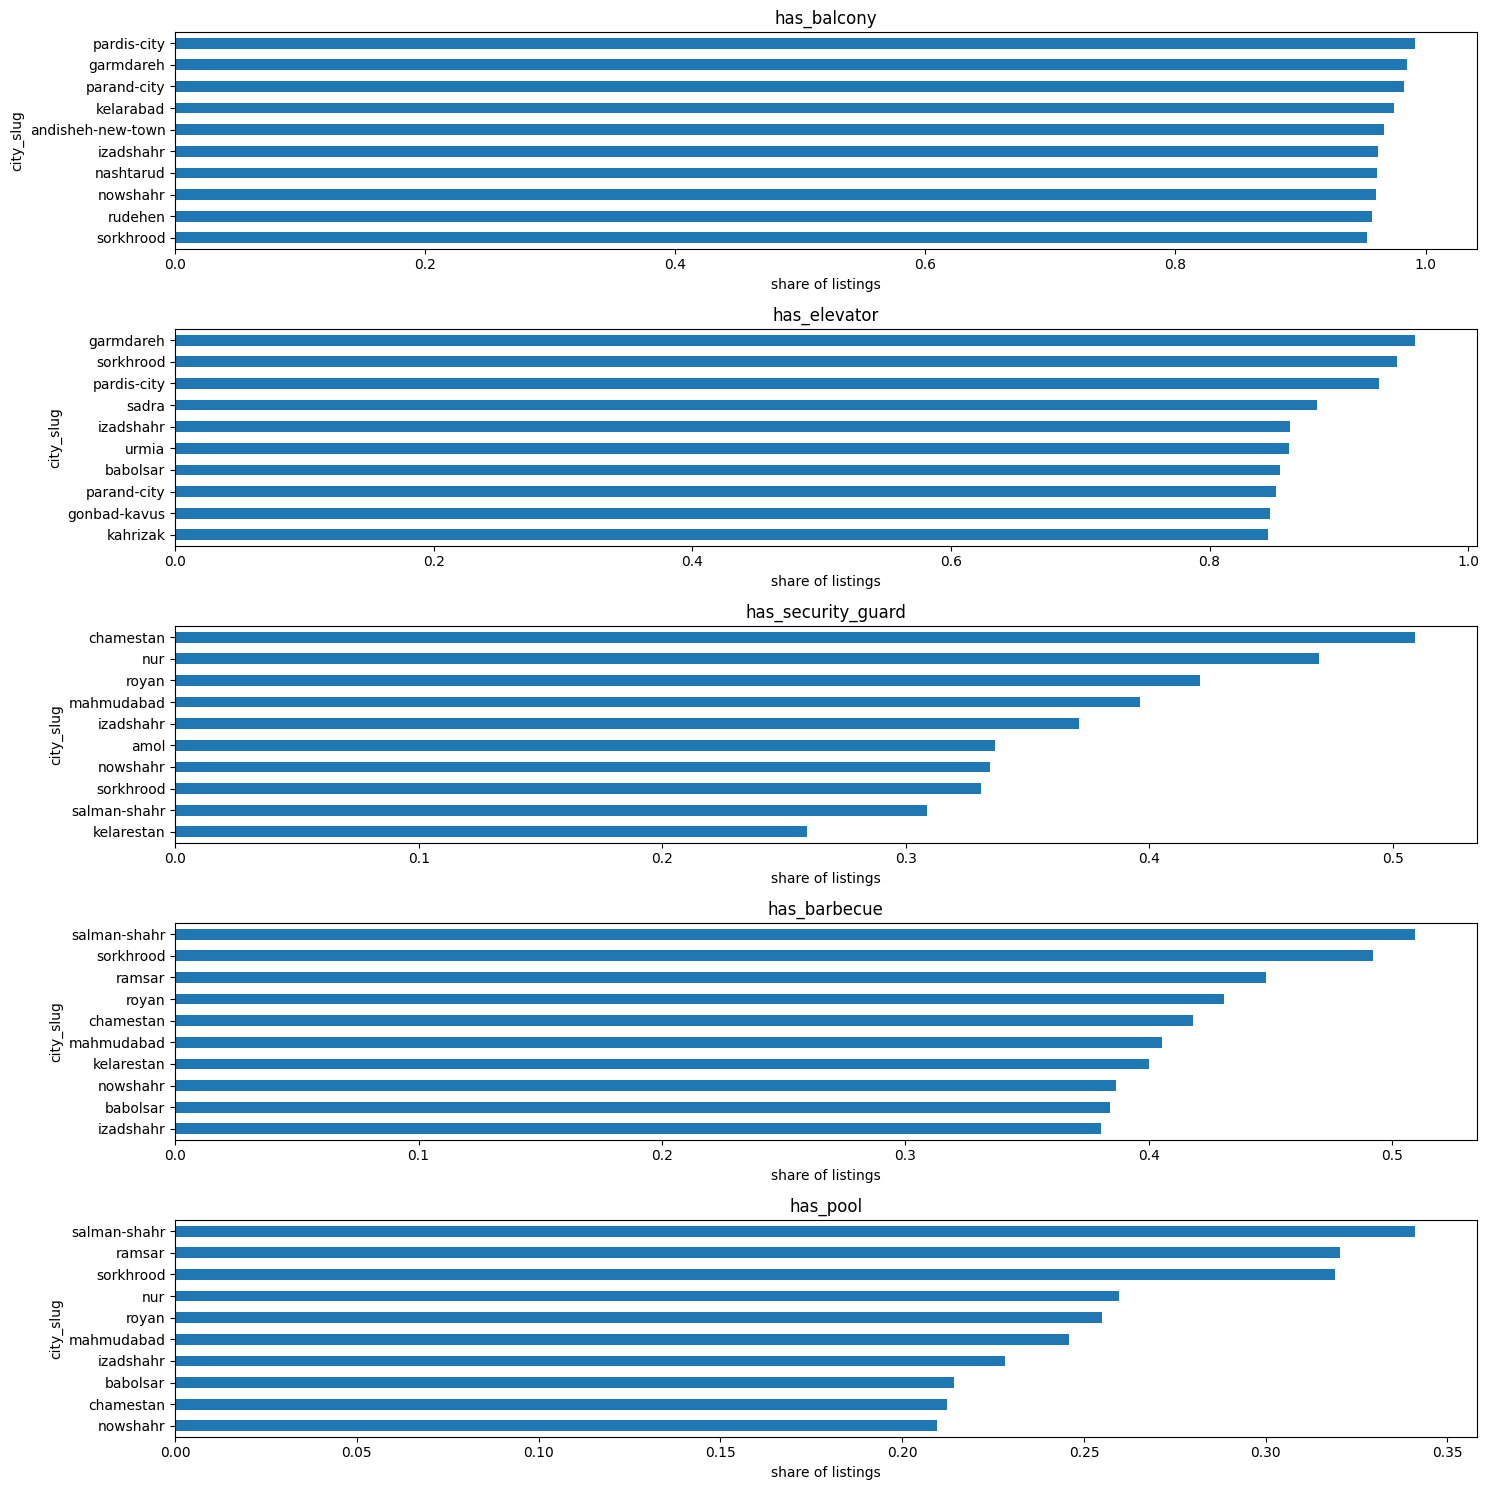

In [21]:
#plt
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(15, 15))
for i, col in enumerate(options_cols):
    shares_ok[col].dropna().sort_values(ascending=False).head(10)[::-1].plot(kind='barh',ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('share of listings')

plt.tight_layout()
plt.show()

<p dir="rtl" align="right"><font color="#90EE90" face="vazir">
دو الگوی کاملا جدا بیرون آمد که اولی بالکن و آسانسور است و بالای فهرستش شهرهای جدید مثل پردیس و پرند و اندیشه و گرمدره هستند با نسبت نزدیک صد درصد چون ساختمان‌هایشان نوساز است و در ساخت و ساز جدید بالکن و آسانسور تقریبا استاندارد شده و دومی نگهبان و باربیکیو و استخر است که همه‌اش در شهرهای ساحلی شمال مثل چمستان و نور و رامسر و سلمان‌شهر و محمودآباد جمع شده چون آنجا ویلای تفریحی زیاد است و این امکانات مال ویلاست نه آپارتمان
</font></p>